In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split 
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve 
from sklearn.ensemble import RandomForestClassifier 
from sklearn.model_selection import cross_val_score


In [2]:
df = pd.read_csv('train.csv')
df = df[['Pclass', 'Sex', 'Age', 'Fare', 'Survived', 'Parch', 'SibSp']]
df.dropna(inplace=True)

#convert sex to numbers 0-1
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

print(df.shape)
print(df.isnull().sum())
df.head(10)

(714, 7)
Pclass      0
Sex         0
Age         0
Fare        0
Survived    0
Parch       0
SibSp       0
dtype: int64


,Pclass,Sex,Age,Fare,Survived,Parch,SibSp
0,3,0,22.0,7.2500,0,0,1
1,1,1,38.0,71.2833,1,0,1
2,3,1,26.0,7.9250,1,0,0
3,1,1,35.0,53.1000,1,0,1
4,3,0,35.0,8.0500,0,0,0
6,1,0,54.0,51.8625,0,0,0
7,3,0,2.0,21.0750,0,1,3
8,3,1,27.0,11.1333,1,2,0
9,2,1,14.0,30.0708,1,0,1
10,3,1,4.0,16.7000,1,1,1


In [3]:
#train/test split  

x =df.drop(columns='Survived')
y = df['Survived']

#train split test 
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

#five fold cross validation
 

Model Trained Successfully
Train AUC: 0.9995
Test AUC: 0.8056
Pclass: 0.0816
Sex: 0.2752
Age: 0.2882
Fare: 0.2762
Parch: 0.0364
SibSp: 0.0424
[0.80273834 0.83904665 0.88864097 0.82555781 0.90753284]
Mean AUC: 0.8527
Standard Deviation: 0.0393


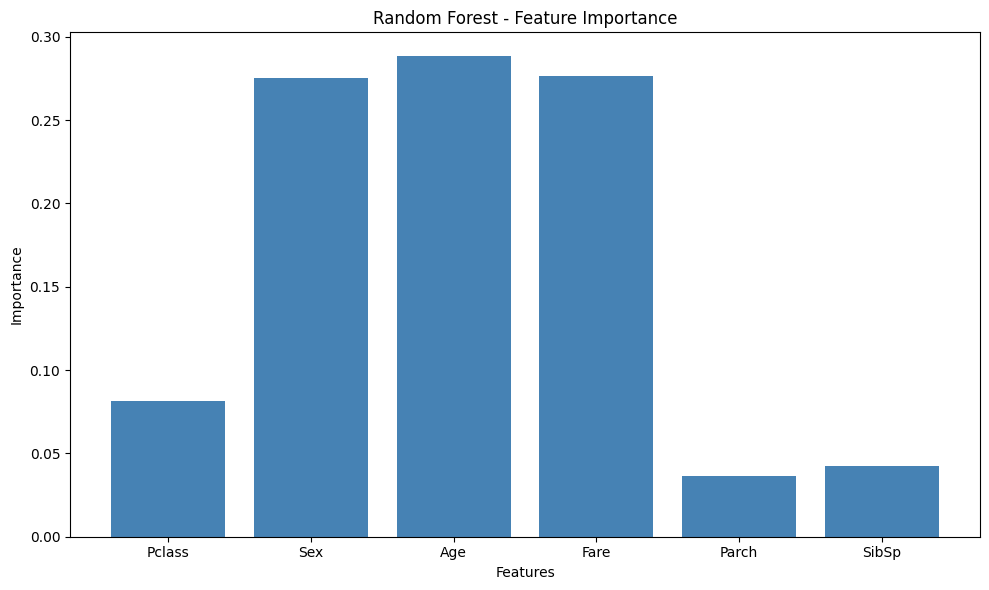

In [5]:
model_rf = RandomForestClassifier(n_estimators = 100, random_state = 42)
model_rf.fit(x_train, y_train)

print("Model Trained Successfully")

train_auc = roc_auc_score(y_train, model_rf.predict_proba(x_train)[:, 1])
test_auc = roc_auc_score(y_test, model_rf.predict_proba(x_test)[:, 1])
print(f"Train AUC: {train_auc:.4f}")
print(f"Test AUC: {test_auc:.4f}")

importances = model_rf.feature_importances_
feature_names = x.columns
for name, importance in zip(feature_names, importances):
    print(f"{name}: {importance:.4f}")

scores = cross_val_score(model_rf, x, y, cv=5, scoring='roc_auc')
print(scores)

print(f"Mean AUC: {scores.mean():.4f}")
print(f"Standard Deviation: {scores.std():.4f}")


#plot bar chart 

plt.figure(figsize=(10, 6))
plt.bar(feature_names, importances, color='steelblue')
plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Random Forest - Feature Importance")
plt.tight_layout()
plt.show()
